# Testing Regressions: Job-ready Graduates Program (DiD)

## Research question
Did Australia's Job-ready Graduates Program (JRGP) change university enrollments relative to a control country (UK) that did not adopt the same policy?

## Identification strategy
- Treatment group: Australia (`treated = 1`)
- Control group: United Kingdom (`treated = 0`)
- Post-policy period: 2021 onward (`post = 1`)
- Policy effect of interest: `treated × post`
- Explicit controls for COVID shock years: 2020 and 2021

## Core specification (two-way fixed effects)
\[
\log(Enrollments_{cft}) = \alpha + \beta (treated_c \times post_t) + \delta_1 COVID2020_t + \delta_2 COVID2021_t + \gamma_f + \lambda_t + \varepsilon_{cft}
\]
where:
- \(c\) = country, \(f\) = field/category, \(t\) = year
- \(\gamma_f\): field fixed effects
- \(\lambda_t\): year fixed effects
- \(\beta\): DiD estimate for JRGP effect

In [1]:
# Core tools for panel setup, visualization, and econometrics
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", context="notebook")

## 1) Load mapped AUS and UK enrollment data

This notebook uses:
- `data/clean/EnrollmentsAUS_category_with_numeric_key.csv`
- `data/clean/uk_grouped/with_categorykey/UK_enrollments_grouped_comparison_all_years_with_categorykey.csv`

The UK file already includes `categorykey`, which lets us align field groups with Australia.

In [3]:
# Paths
# Resolve project root robustly even when notebook runs from docs/Regression Analysis
START = Path.cwd()
ROOT = START
while ROOT != ROOT.parent and not (ROOT / "data").exists():
    ROOT = ROOT.parent

AUS_PATH = ROOT / "data" / "clean" / "EnrollmentsAUS_category_with_numeric_key.csv"
UK_PATH = ROOT / "data" / "clean" / "uk_grouped" / "with_categorykey" / "UK_enrollments_grouped_comparison_all_years_with_categorykey.csv"

print("Working directory:", START)
print("Resolved project root:", ROOT)
print("AUS file exists:", AUS_PATH.exists(), AUS_PATH)
print("UK file exists:", UK_PATH.exists(), UK_PATH)

# Load Australia data (wide years -> long panel)
aus_raw = pd.read_csv(AUS_PATH)
year_cols = [c for c in aus_raw.columns if str(c).isdigit()]

aus_long = aus_raw.melt(
    id_vars=["Category", "CategoryKey"],
    value_vars=year_cols,
    var_name="year",
    value_name="enrollments",
)
aus_long["year"] = aus_long["year"].astype(int)
aus_long["categorykey"] = pd.to_numeric(aus_long["CategoryKey"], errors="coerce")
aus_long["field_name"] = aus_long["Category"].astype(str).str.strip()
aus_long["country"] = "AUS"
aus_long = aus_long[["country", "year", "categorykey", "field_name", "enrollments"]]

# Load UK mapped data (already long by academic year and field)
uk_raw = pd.read_csv(UK_PATH)
uk_raw["categorykey"] = pd.to_numeric(uk_raw["categorykey"], errors="coerce")
uk_raw["field_name"] = uk_raw["Subject"].astype(str).str.strip()
uk_raw["enrollments"] = pd.to_numeric(uk_raw["Total UK"], errors="coerce")

# Convert academic year like 2020/21 -> 2021
uk_raw["year"] = uk_raw["AcademicYear"].astype(str).str.extract(r"/(\d{2})$").iloc[:, 0]
uk_raw["year"] = 2000 + pd.to_numeric(uk_raw["year"], errors="coerce")
uk_raw["country"] = "UK"
uk_long = uk_raw[["country", "year", "categorykey", "field_name", "enrollments"]]

print("AUS rows:", len(aus_long), "| UK rows:", len(uk_long))
aus_long.head()

Working directory: c:\Users\neddp\ECC3479-Project-JRGS\docs\Regression Analysis
Resolved project root: c:\Users\neddp\ECC3479-Project-JRGS
AUS file exists: True c:\Users\neddp\ECC3479-Project-JRGS\data\clean\EnrollmentsAUS_category_with_numeric_key.csv
UK file exists: True c:\Users\neddp\ECC3479-Project-JRGS\data\clean\uk_grouped\with_categorykey\UK_enrollments_grouped_comparison_all_years_with_categorykey.csv
AUS rows: 108 | UK rows: 282


,country,year,categorykey,field_name,enrollments
0,AUS,2016,1,Natural & Physical Science,119102
1,AUS,2016,2,Information Technology,66355
2,AUS,2016,3,Engineering & Related Tech,111060
3,AUS,2016,4,Architecture & Building,32074
4,AUS,2016,5,Environment & Related,18537


In [4]:
# Build combined panel and treatment indicators
panel = pd.concat([aus_long, uk_long], ignore_index=True)

# Keep overlapping window where AUS data is available and enough pre/post variation exists
panel = panel[(panel["year"] >= 2016) & (panel["year"] <= 2024)].copy()

# Keep mapped categories only
panel = panel.dropna(subset=["categorykey", "enrollments", "year"]).copy()
panel["categorykey"] = panel["categorykey"].astype(int)
panel["enrollments"] = pd.to_numeric(panel["enrollments"], errors="coerce")

# Aggregate within country-year-category in case of duplicate rows
panel = (
    panel.groupby(["country", "year", "categorykey"], as_index=False)["enrollments"]
    .sum()
)

# DiD variables
panel["treated"] = (panel["country"] == "AUS").astype(int)
panel["post"] = (panel["year"] >= 2021).astype(int)  # JRGP starts 2021
panel["did"] = panel["treated"] * panel["post"]
panel["covid_2020"] = (panel["year"] == 2020).astype(int)
panel["covid_2021"] = (panel["year"] == 2021).astype(int)

# Outcome transforms
panel = panel[panel["enrollments"] > 0].copy()
panel["log_enrollments"] = np.log(panel["enrollments"])

print("Panel shape:", panel.shape)
print("Years:", sorted(panel["year"].unique()))
print("Categories:", panel["categorykey"].nunique())
panel.head()

Panel shape: (192, 10)
Years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Categories: 12


,country,year,categorykey,enrollments,treated,post,did,covid_2020,covid_2021,log_enrollments
0,AUS,2016,1,119102.0,1,0,0,0,0,11.687736
1,AUS,2016,2,66355.0,1,0,0,0,0,11.102774
2,AUS,2016,3,111060.0,1,0,0,0,0,11.617826
3,AUS,2016,4,32074.0,1,0,0,0,0,10.375801
4,AUS,2016,5,18537.0,1,0,0,0,0,9.827524


Country-year totals preview:


,country,year,enrollments,log_enrollments
0,AUS,2016,2989661.0,14.910671
1,AUS,2017,3104770.0,14.948450
2,AUS,2018,3205429.0,14.980356
3,AUS,2019,3300940.0,15.009718
4,AUS,2020,3327605.0,15.017763
5,AUS,2021,3289074.0,15.006117
6,AUS,2022,3183837.0,14.973598
7,AUS,2023,3278695.0,15.002956
8,AUS,2024,3430250.0,15.048144
9,UK,2016,6842480.0,15.738661


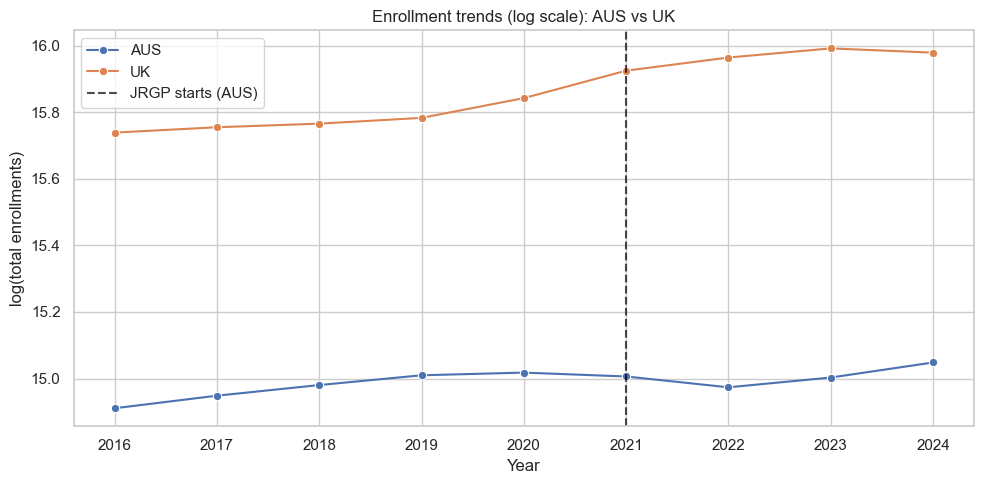

In [5]:
# Quick diagnostics: balance and pre-trends visual check
summary = (
    panel.groupby(["country", "year"], as_index=False)["enrollments"]
    .sum()
)
summary["log_enrollments"] = np.log(summary["enrollments"])

print("Country-year totals preview:")
display(summary.head(10))

plt.figure(figsize=(10, 5))
sns.lineplot(data=summary, x="year", y="log_enrollments", hue="country", marker="o")
plt.axvline(2021, linestyle="--", color="black", alpha=0.7, label="JRGP starts (AUS)")
plt.title("Enrollment trends (log scale): AUS vs UK")
plt.xlabel("Year")
plt.ylabel("log(total enrollments)")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# Baseline DiD (two-way fixed effects)
# With year FE, common COVID year shocks are absorbed by C(year).
# To explicitly control differential COVID impact on Australia, include treated-specific COVID interactions.
formula_twfe = (
    "log_enrollments ~ did + treated:covid_2020 + treated:covid_2021 "
    "+ C(categorykey) + C(year)"
)

did_twfe = smf.ols(formula_twfe, data=panel).fit(
    cov_type="cluster",
    cov_kwds={"groups": panel["categorykey"]}
)

print(did_twfe.summary())

beta = did_twfe.params.get("did", np.nan)
se = did_twfe.bse.get("did", np.nan)
pval = did_twfe.pvalues.get("did", np.nan)

print(f"\nDiD estimate (did): {beta:.4f}")
print(f"SE: {se:.4f} | p-value: {pval:.4f}")
if pd.notna(beta):
    print(f"Approx. percent effect: {(np.exp(beta)-1)*100:.2f}%")

                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       0.690
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                 6.006e+04
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           1.26e-24
Time:                        11:28:35   Log-Likelihood:                -221.46
No. Observations:                 192   AIC:                             488.9
Df Residuals:                     169   BIC:                             563.8
Df Model:                          22                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               12.0868 

c:\Users\neddp\ECC3479-Project-JRGS\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 22, but rank is 11
  warnings.warn('covariance of constraints does not have full '


,rel_year,beta,lb,ub
0,-4,-0.699364,-2.794458,1.395730
1,-3,-0.677282,-2.763471,1.408908
2,-2,-0.661504,-2.726387,1.403379
3,-1,-0.644937,-2.692678,1.402803
4,1,-0.285087,-0.397056,-0.173119
5,2,-0.633506,-0.859759,-0.407253
6,3,-0.619625,-0.853121,-0.386129
7,4,-0.549580,-0.803478,-0.295683


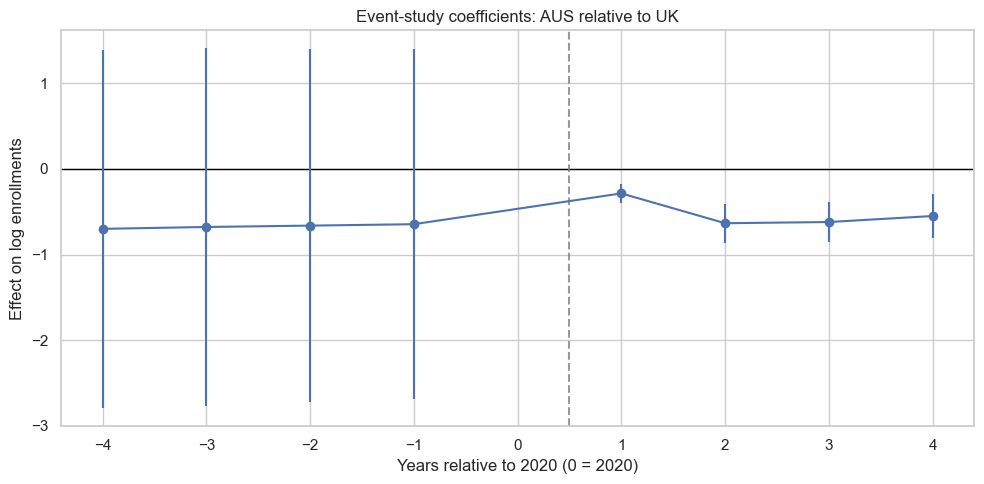

In [10]:
# Parallel trends check: event-study with explicit treated-by-event dummies
panel_es = panel.copy()
panel_es["rel_year"] = panel_es["year"] - 2020
panel_es = panel_es[(panel_es["rel_year"] >= -4) & (panel_es["rel_year"] <= 4)].copy()

# Build treated-by-event dummies and omit rel_year = 0 as reference
event_terms = []
term_map = {}
for k in range(-4, 5):
    if k == 0:
        continue
    prefix = "m" if k < 0 else "p"
    col = f"event_{prefix}{abs(k)}"
    panel_es[col] = ((panel_es["rel_year"] == k) & (panel_es["treated"] == 1)).astype(int)
    event_terms.append(col)
    term_map[col] = k

event_formula = (
    "log_enrollments ~ "
    + " + ".join(event_terms)
    + " + treated:covid_2020 + treated:covid_2021 + C(categorykey) + C(year)"
)

event_mod = smf.ols(event_formula, data=panel_es).fit(
    cov_type="cluster",
    cov_kwds={"groups": panel_es["categorykey"]}
)

rows = []
for col, k in term_map.items():
    if col in event_mod.params.index:
        b = event_mod.params[col]
        s = event_mod.bse[col]
        rows.append((k, b, b - 1.96 * s, b + 1.96 * s))

ev = pd.DataFrame(rows, columns=["rel_year", "beta", "lb", "ub"]).sort_values("rel_year")
display(ev)

if not ev.empty:
    plt.figure(figsize=(10, 5))
    plt.axhline(0, color="black", linewidth=1)
    plt.axvline(0.5, color="gray", linestyle="--", alpha=0.8)
    plt.errorbar(ev["rel_year"], ev["beta"], yerr=[ev["beta"]-ev["lb"], ev["ub"]-ev["beta"]], fmt="o-")
    plt.title("Event-study coefficients: AUS relative to UK")
    plt.xlabel("Years relative to 2020 (0 = 2020)")
    plt.ylabel("Effect on log enrollments")
    plt.tight_layout()
    plt.show()

## 2) Notes for write-up (aligned with regression slides)

When reporting results, include:
1. The identifying assumption: AUS and UK would have followed parallel enrollment trends absent JRGP.
2. The coefficient of interest: `did` (AUS × post-2021).
3. Why fixed effects are included: category and year FE absorb time-invariant field differences and common shocks.
4. Why COVID controls are explicit: 2020 and 2021 disruptions may bias policy attribution.
5. Pre-trend evidence: discuss event-study leads before 2021.

Suggested robustness checks:
- Re-estimate with outcome in levels instead of logs.
- Drop 2020 entirely and compare estimates.
- Add country-specific linear trends (`treated * year`) and inspect sensitivity.
- Restrict to categories with strong AUS-UK comparability if needed.

## 3) Discipline-specific DiD regressions (one model per category)

This section estimates a separate DiD model for each discipline/category (for example IT, Management, Engineering).

Per-category model:
\[
\log(Enrollments_{ct}) = \alpha + \beta (treated_c \times post_t) + \theta_1(treated_c \times COVID2020_t) + \theta_2(treated_c \times COVID2021_t) + \lambda_t + \varepsilon_{ct}
\]

Notes:
- `\beta` is the discipline-specific JRGP effect.
- Year fixed effects (`\lambda_t`) absorb common annual shocks.
- We use heteroskedasticity-robust (`HC1`) standard errors due small per-discipline samples.

In [11]:
# Build readable category labels from AUS file
category_labels = (
    aus_raw[["CategoryKey", "Category"]]
    .drop_duplicates()
    .rename(columns={"CategoryKey": "categorykey", "Category": "discipline"})
)
category_labels["categorykey"] = pd.to_numeric(category_labels["categorykey"], errors="coerce").astype("Int64")
category_labels = category_labels.dropna(subset=["categorykey"]).copy()
category_labels["categorykey"] = category_labels["categorykey"].astype(int)

# Run one DiD regression per category
discipline_rows = []
formula_cat = "log_enrollments ~ did + treated:covid_2020 + treated:covid_2021 + C(year)"

for k in sorted(panel["categorykey"].unique()):
    d = panel[panel["categorykey"] == k].copy()

    # Require both countries and at least one pre and post year
    if d["country"].nunique() < 2 or d.loc[d["post"] == 0].empty or d.loc[d["post"] == 1].empty:
        continue

    try:
        m = smf.ols(formula_cat, data=d).fit(cov_type="HC1")
        b = m.params.get("did", np.nan)
        s = m.bse.get("did", np.nan)
        p = m.pvalues.get("did", np.nan)

        discipline_rows.append(
            {
                "categorykey": int(k),
                "discipline": category_labels.loc[category_labels["categorykey"] == int(k), "discipline"].iloc[0]
                if (category_labels["categorykey"] == int(k)).any()
                else f"Category {int(k)}",
                "did_beta_log_points": b,
                "did_se": s,
                "did_pvalue": p,
                "did_pct_effect": (np.exp(b) - 1) * 100 if pd.notna(b) else np.nan,
                "n_obs": int(m.nobs),
                "r2": m.rsquared,
            }
        )
    except Exception as ex:
        discipline_rows.append(
            {
                "categorykey": int(k),
                "discipline": category_labels.loc[category_labels["categorykey"] == int(k), "discipline"].iloc[0]
                if (category_labels["categorykey"] == int(k)).any()
                else f"Category {int(k)}",
                "did_beta_log_points": np.nan,
                "did_se": np.nan,
                "did_pvalue": np.nan,
                "did_pct_effect": np.nan,
                "n_obs": len(d),
                "r2": np.nan,
                "error": str(ex),
            }
        )

results_by_discipline = pd.DataFrame(discipline_rows).sort_values("did_pvalue", na_position="last")

print("Discipline-specific DiD results:")
display(results_by_discipline)

# Quick significant-effects view at 10% and 5%
if not results_by_discipline.empty:
    sig10 = (results_by_discipline["did_pvalue"] < 0.10).sum()
    sig05 = (results_by_discipline["did_pvalue"] < 0.05).sum()
    print(f"Significant at 10%: {sig10} / {len(results_by_discipline)}")
    print(f"Significant at 5% : {sig05} / {len(results_by_discipline)}")

Discipline-specific DiD results:


,categorykey,discipline,did_beta_log_points,did_se,did_pvalue,did_pct_effect,n_obs,r2
0,1,Natural & Physical Science,-0.537572,0.011631,0.000000e+00,-41.583488,18,0.259208
4,5,Environment & Related,-1.213983,0.004188,0.000000e+00,-70.298808,18,0.389929
11,99,Total,-1.281939,0.020256,0.000000e+00,-72.250118,18,0.614661
8,9,Society & Culture,-0.860296,0.009223,0.000000e+00,-57.696330,18,0.478766
5,6,Health,-0.477021,0.014380,2.680279e-241,-37.937079,18,0.641102
7,8,Management & Commerce,-0.469749,0.020509,4.218729e-116,-37.484106,14,0.998795
9,10,Creative Arts,-0.687258,0.036096,7.958189e-81,-49.704663,14,0.998856
3,4,Architecture & Building,-0.450859,0.033945,2.938989e-40,-36.291918,14,0.998119
2,3,Engineering & Related Tech,-0.459443,0.068187,1.605827e-11,-36.836476,14,0.990890
10,11,Others,-0.640468,0.101165,2.437401e-10,-47.295422,18,0.378310


Significant at 10%: 11 / 12
Significant at 5% : 11 / 12


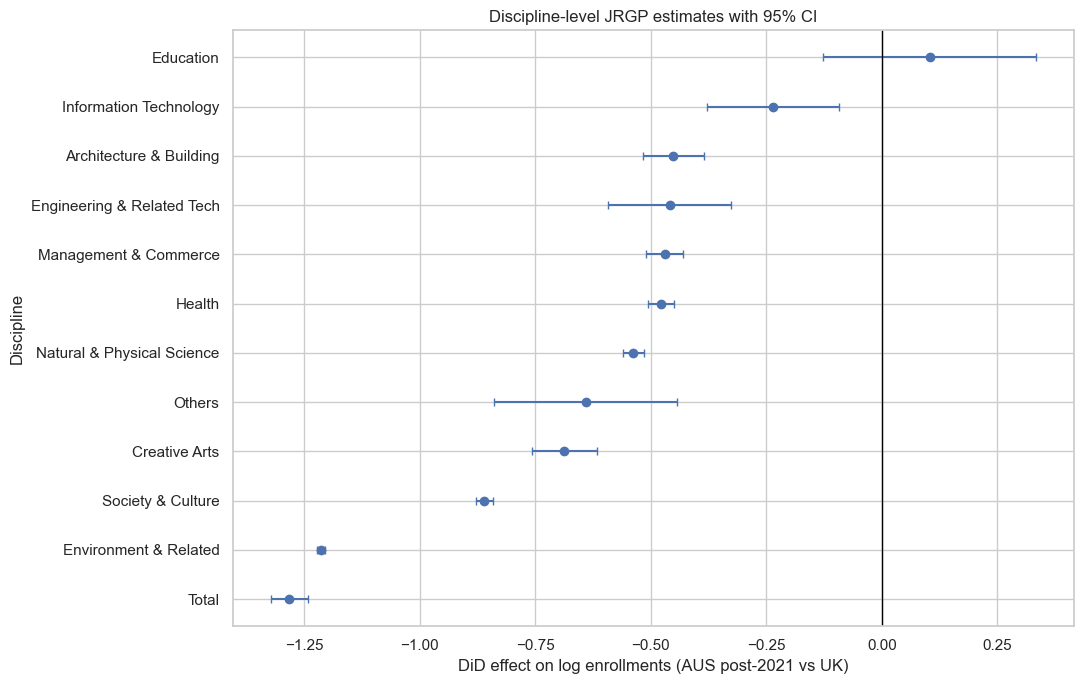

In [12]:
# Visualize discipline-specific JRGP effects with 95% confidence intervals
plot_df = results_by_discipline.dropna(subset=["did_beta_log_points", "did_se"]).copy()
plot_df["lb"] = plot_df["did_beta_log_points"] - 1.96 * plot_df["did_se"]
plot_df["ub"] = plot_df["did_beta_log_points"] + 1.96 * plot_df["did_se"]
plot_df = plot_df.sort_values("did_beta_log_points")

if not plot_df.empty:
    plt.figure(figsize=(11, 7))
    y = np.arange(len(plot_df))
    plt.errorbar(
        plot_df["did_beta_log_points"],
        y,
        xerr=[plot_df["did_beta_log_points"] - plot_df["lb"], plot_df["ub"] - plot_df["did_beta_log_points"]],
        fmt="o",
        capsize=3,
    )
    plt.axvline(0, color="black", linewidth=1)
    plt.yticks(y, plot_df["discipline"])
    plt.xlabel("DiD effect on log enrollments (AUS post-2021 vs UK)")
    plt.ylabel("Discipline")
    plt.title("Discipline-level JRGP estimates with 95% CI")
    plt.tight_layout()
    plt.show()

## 4) Paper-style regression equations

Use this notation in your write-up.

### Baseline DiD (all disciplines pooled)
$$
Y_{cft} = \beta_0 + \beta_1\,(\text{Treated}_c \times \text{Post}_t) + \beta_2\,(\text{Treated}_c \times \text{COVID2020}_t) + \beta_3\,(\text{Treated}_c \times \text{COVID2021}_t) + \gamma_f + \lambda_t + \varepsilon_{cft}
$$

Where:
- $Y_{cft} = \log(\text{Enrollments}_{cft})$
- $\beta_1$ is the JRGP treatment effect (DiD estimate)
- $\gamma_f$ are discipline fixed effects
- $\lambda_t$ are year fixed effects

### Equivalent "beta-x" form
$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \text{FE} + \varepsilon
$$
with:
- $X_1 = \text{Treated} \times \text{Post}$
- $X_2 = \text{Treated} \times \text{COVID2020}$
- $X_3 = \text{Treated} \times \text{COVID2021}$

### Discipline-specific model (run separately for each discipline $f$)
$$
Y_{ct}^{(f)} = \alpha_f + \theta_{1f}(\text{Treated}_c \times \text{Post}_t) + \theta_{2f}(\text{Treated}_c \times \text{COVID2020}_t) + \theta_{3f}(\text{Treated}_c \times \text{COVID2021}_t) + \lambda_t + u_{ct}^{(f)}
$$

Interpretation:
- $\theta_{1f}$ is the JRGP effect for discipline $f$ (for example IT, Management, Engineering).

## 5) Example comparison regression: Arts (2019 vs 2021 vs 2024)

This is a focused example for **Creative Arts** using only years 2019, 2021, and 2024.

Regression setup (2019 is baseline):
\[
\log(Enrollments) = \alpha + \beta_1\,Treated + \beta_2\,Year2021 + \beta_3\,Year2024 + \beta_4\,(Treated\times Year2021) + \beta_5\,(Treated\times Year2024) + \varepsilon
\]

Interpretation:
- $\beta_4$: how Australia's Arts enrollments changed in 2021 relative to UK, compared with 2019.
- $\beta_5$: how Australia's Arts enrollments changed in 2024 relative to UK, compared with 2019.

In [15]:
# Example comparison regression for Creative Arts: 2019 vs 2021 vs 2024
# Build a dedicated panel where UK academic years are mapped to START year
# (e.g., 2019/20 -> 2019) so each requested comparison year is present in both countries.

# Identify Creative Arts key
arts_candidates = category_labels[
    category_labels["discipline"].str.contains("creative", case=False, na=False)
].copy()
if arts_candidates.empty:
    raise ValueError("Could not find a Creative Arts category in category_labels.")

arts_key = int(arts_candidates.iloc[0]["categorykey"])
arts_name = arts_candidates.iloc[0]["discipline"]

# AUS component from existing long data
aus_ex = aus_long[aus_long["year"].isin([2019, 2021, 2024])].copy()
aus_ex["enrollments"] = pd.to_numeric(aus_ex["enrollments"], errors="coerce")
aus_ex = aus_ex[["country", "year", "categorykey", "enrollments"]]

# UK component from mapped raw data, using start year from AcademicYear
uk_ex = uk_raw.copy()
uk_ex["year_start"] = pd.to_numeric(
    uk_ex["AcademicYear"].astype(str).str.extract(r"^(\d{4})/").iloc[:, 0],
    errors="coerce",
)
uk_ex = uk_ex[uk_ex["year_start"].isin([2019, 2021, 2024])].copy()
uk_ex["country"] = "UK"
uk_ex["year"] = uk_ex["year_start"].astype(int)
uk_ex["enrollments"] = pd.to_numeric(uk_ex["Total UK"], errors="coerce")
uk_ex = uk_ex[["country", "year", "categorykey", "enrollments"]]

# Combine and aggregate to country-year-category
ex_df = pd.concat([aus_ex, uk_ex], ignore_index=True)
ex_df = ex_df.dropna(subset=["categorykey", "enrollments"]).copy()
ex_df["categorykey"] = pd.to_numeric(ex_df["categorykey"], errors="coerce").astype(int)
ex_df = (
    ex_df.groupby(["country", "year", "categorykey"], as_index=False)["enrollments"]
    .sum()
)

# Construct model variables
ex_df["log_enrollments"] = np.log(ex_df["enrollments"])
ex_df["treated"] = (ex_df["country"] == "AUS").astype(int)
ex_df["arts"] = (ex_df["categorykey"] == arts_key).astype(int)
ex_df["y2021"] = (ex_df["year"] == 2021).astype(int)
ex_df["y2024"] = (ex_df["year"] == 2024).astype(int)

print(f"Using category: {arts_name} (key={arts_key})")

print("\nCreative Arts raw enrollments (AUS vs UK):")
arts_raw = ex_df[ex_df["arts"] == 1][["country", "year", "enrollments", "log_enrollments"]].sort_values(["year", "country"])
display(arts_raw)

# Triple-interaction style model to isolate Arts-specific treatment changes in 2021 and 2024
formula_arts_example = (
    "log_enrollments ~ treated + y2021 + y2024 + arts "
    "+ treated:y2021 + treated:y2024 "
    "+ treated:arts + arts:y2021 + arts:y2024 "
    "+ treated:arts:y2021 + treated:arts:y2024"
)

arts_example_model = smf.ols(formula_arts_example, data=ex_df).fit(cov_type="HC1")

coef_table = pd.DataFrame({
    "coef": arts_example_model.params,
    "std_err": arts_example_model.bse,
    "p_value": arts_example_model.pvalues,
})

print("\nKey coefficient table:")
display(coef_table)

# Recover Arts-specific AUS-vs-UK changes vs 2019 baseline
b_ty2021 = arts_example_model.params.get("treated:y2021", 0.0)
b_ta2021 = arts_example_model.params.get("treated:arts:y2021", 0.0)
b_ty2024 = arts_example_model.params.get("treated:y2024", 0.0)
b_ta2024 = arts_example_model.params.get("treated:arts:y2024", 0.0)

arts_eff_2021 = b_ty2021 + b_ta2021
arts_eff_2024 = b_ty2024 + b_ta2024

arts_pct_2021 = (np.exp(arts_eff_2021) - 1) * 100
arts_pct_2024 = (np.exp(arts_eff_2024) - 1) * 100

print("\nSimple summary (for write-up):")
print(
    f"Relative to 2019, Australia’s {arts_name} enrollments in 2021 were about {arts_pct_2021:.1f}% different than the UK benchmark."
)
print(
    f"Relative to 2019, Australia’s {arts_name} enrollments in 2024 were about {arts_pct_2024:.1f}% different than the UK benchmark."
)

if arts_pct_2024 > arts_pct_2021:
    print("The 2024 result is less negative/more positive than 2021, suggesting partial recovery over time.")
else:
    print("The 2024 result is more negative than 2021, suggesting weaker relative performance over time.")

Using category: Creative Arts (key=10)

Creative Arts raw enrollments (AUS vs UK):


,country,year,enrollments,log_enrollments
9,AUS,2019,97478.0,11.487382
45,UK,2019,187045.0,12.139105
21,AUS,2021,98528.0,11.498096
57,UK,2021,189930.0,12.154411
33,AUS,2024,96142.0,11.473582
69,UK,2024,178755.0,12.093771



Key coefficient table:


,coef,std_err,p_value
Intercept,12.300851,0.430584,1.687109e-179
treated,-0.456252,0.583806,4.345004e-01
y2021,0.115292,0.612286,8.506434e-01
y2024,0.096743,0.620004,8.760049e-01
arts,-0.161747,0.430584,7.071809e-01
treated:y2021,-0.144053,0.835304,8.630797e-01
treated:y2024,-0.061188,0.838070,9.417976e-01
treated:arts,-0.195470,0.583806,7.377607e-01
arts:y2021,-0.099986,0.612286,8.702832e-01
arts:y2024,-0.142076,0.620004,8.187500e-01



Simple summary (for write-up):
Relative to 2019, Australia’s Creative Arts enrollments in 2021 were about -0.5% different than the UK benchmark.
Relative to 2019, Australia’s Creative Arts enrollments in 2024 were about 3.2% different than the UK benchmark.
The 2024 result is less negative/more positive than 2021, suggesting partial recovery over time.


## 6) Short simple write-up summary (Creative Arts example)

This auto-generates a plain-English paragraph you can copy into your report.

In [16]:
# Short plain-English summary paragraph for the Arts example
p_2021_key = arts_example_model.pvalues.get("treated:arts:y2021", np.nan)
p_2024_key = arts_example_model.pvalues.get("treated:arts:y2024", np.nan)

strength_msg = (
    "The p-values are high, so this is weak statistical evidence and should be interpreted cautiously."
    if (pd.notna(p_2021_key) and pd.notna(p_2024_key) and (p_2021_key >= 0.05 and p_2024_key >= 0.05))
    else "At least one key term is statistically meaningful at the 5% level."
)

summary_text = (
    f"For Creative Arts, Australia is very close to the UK benchmark in 2021 relative to 2019 "
    f"({arts_pct_2021:.1f}%). By 2024, Australia is slightly above the UK benchmark relative to 2019 "
    f"({arts_pct_2024:.1f}%), which suggests some recovery over time. {strength_msg}"
)

print("Short simple write-up:")
print(summary_text)

Short simple write-up:
For Creative Arts, Australia is very close to the UK benchmark in 2021 relative to 2019 (-0.5%). By 2024, Australia is slightly above the UK benchmark relative to 2019 (3.2%), which suggests some recovery over time. The p-values are high, so this is weak statistical evidence and should be interpreted cautiously.
